## 1. Import Libraries and Setup

In [39]:
import math
import matplotlib.pyplot as plt
import autograd.numpy as np
import autograd.numpy as sqrt
from autograd.numpy.linalg import norm
from autograd.numpy.linalg import inv
from autograd import jacobian
from autograd.test_util import check_grads
from control import dlqr
import time
from scipy.spatial.transform import Rotation as spRot
from scipy.linalg import solve_discrete_are
np.set_printoptions(precision=4, suppress=True)

# Quadrotor physical parameters
mass = 0.035  # kg
J = np.array([[16.6e-6, 0.83e-6, 0.72e-6],
              [0.83e-6, 16.6e-6, 1.8e-6],
              [0.72e-6, 1.8e-6, 29.3e-6]])  # kg*m^2
g = 9.81  # m/s^2
thrustToTorque = 0.0008
el = 0.046/1.414213562  # m
scale = 65535
kt = 2.245365e-6*scale
km = kt*thrustToTorque

# Control parameters
freq = 50.0  # Hz
h = 1/freq   # sampling time
Nx1 = 13     # full state dimension (with quaternions)
Nx = 12      # reduced state dimension (error coordinates)
Nu = 4       # control dimension

# Figure-8 trajectory parameters
A_fig8 = 0.5
w_fig8 = 2*np.pi/7

In [40]:
# Generate comprehensive visualization
def create_comprehensive_plots(results_list, T_sim, labels=None, colors=None):
    """Create comprehensive comparison plots for flat figure-8 trajectory.
    
    Args:
        results_list: list of tuples, each (x_traj, u_traj, iter_list, status_list)
        T_sim: total simulation time
        labels: optional list of labels (same length as results_list)
        colors: optional list of colors (same length as results_list)
        
    Returns:
        errors_xy: list of position error arrays for each controller
        efforts: list of control effort arrays for each controller
    """
    
    # Time vectors
    n_steps = results_list[0][0].shape[1]
    t = np.linspace(0, T_sim, n_steps)
    t_u = np.linspace(0, T_sim, results_list[0][1].shape[1])
    
    # Reference trajectory
    x_ref = np.array([generate_figure8_reference(t_i) for t_i in t]).T
    
    # Defaults for labels/colors
    if labels is None:
        labels = [f"Controller {i+1}" for i in range(len(results_list))]
    if colors is None:
        base_colors = ['b','r','g','m','c','y','tab:orange','tab:purple']
        colors = [base_colors[i % len(base_colors)] for i in range(len(results_list))]
    
    fig = plt.figure(figsize=(18, 12))
    
    # 1) 2D Trajectory (X-Y)
    ax1 = plt.subplot(2, 4, 1)
    plt.plot(x_ref[0, :], x_ref[1, :], 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        plt.plot(x_traj[0, :], x_traj[1, :], '-', linewidth=2, label=lab, color=col)
    plt.xlabel('X Position [m]')
    plt.ylabel('Y Position [m]')
    plt.title('Flat Figure-8 Trajectory Comparison (X-Y)')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2) X Position vs Time
    ax2 = plt.subplot(2, 4, 2)
    plt.plot(t, x_ref[0, :], 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        plt.plot(t, x_traj[0, :], '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('X Position [m]')
    plt.title('X Position Tracking')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3) Y Position vs Time
    ax3 = plt.subplot(2, 4, 3)
    plt.plot(t, x_ref[1, :], 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        plt.plot(t, x_traj[1, :], '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('Y Position [m]')
    plt.title('Y Position Tracking')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4) Position Tracking Error (X-Y)
    ax4 = plt.subplot(2, 4, 4)
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        # Calculate position error (X-Y)
        err_xy = np.linalg.norm(x_traj[[0,1], :] - x_ref[[0,1], :], axis=0)
        plt.plot(t, err_xy, '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('Position Error [m]')
    plt.title('Position Tracking Error (X-Y)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # 5) Control Inputs
    ax5 = plt.subplot(2, 4, 5)
    for (_, u_traj, _, _), lab, col in zip(results_list, labels, colors):
        for i in range(Nu):
            plt.plot(t_u, u_traj[i, :], '-', alpha=0.7, linewidth=1, color=col)
    plt.axhline(y=uhover[0], color='k', linestyle='--', alpha=0.5, label='Hover')
    plt.xlabel('Time [s]')
    plt.ylabel('Control Input')
    plt.title('Control Inputs')
    plt.grid(True, alpha=0.3)
    
    # 6) Control Effort
    ax6 = plt.subplot(2, 4, 6)
    for (_, u_traj, _, _), lab, col in zip(results_list, labels, colors):
        effort = np.linalg.norm(u_traj - uhover.reshape(-1,1), axis=0)
        plt.plot(t_u, effort, '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('Control Effort')
    plt.title('Control Effort (Deviation from Hover)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7) ADMM Iterations
    ax7 = plt.subplot(2, 4, 7)
    for (_, _, iters, _), lab, col in zip(results_list, labels, colors):
        plt.plot(t_u, iters, '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('ADMM Iterations')
    plt.title('ADMM Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 8) 3D Trajectory (X-Y-Time)
    ax8 = plt.subplot(2, 4, 8, projection='3d')
    ax8.plot(x_ref[0, :], x_ref[1, :], t, 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        ax8.plot(x_traj[0, :], x_traj[1, :], t, '-', linewidth=2, label=lab, color=col)
    ax8.set_xlabel('X [m]')
    ax8.set_ylabel('Y [m]')
    ax8.set_zlabel('Time [s]')
    ax8.set_title('3D Trajectory (X-Y-Time)')
    ax8.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig('controller_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Performance summary table
    print("\nPerformance Summary:")
    print("-" * 80)
    print(f"{'Controller':<20} {'Type':<10} {'Avg Error':<12} {'Max Error':<12} {'Avg Effort':<12} {'Avg Iters':<10}")
    print("-" * 80)
    
    # Calculate and return metrics
    errors_xy = []
    efforts = []
    controller_metrics = []
    
    for i, ((x_traj, u_traj, iters, _), lab) in enumerate(zip(results_list, labels)):
        # Calculate error and effort metrics
        err_xy = np.linalg.norm(x_traj[[0,1], :] - x_ref[[0,1], :], axis=0)
        effort = np.linalg.norm(u_traj - uhover.reshape(-1,1), axis=0)
        
        errors_xy.append(err_xy)
        efforts.append(effort)
        
        # Determine controller type from iterations (approximation)
        is_tinympc = np.mean(iters) > 1.5
        ctrl_type = "TinyMPC" if is_tinympc else "LQR"
        
        # Print summary stats
        print(f"{lab:<20} {ctrl_type:<10} {np.mean(err_xy):<12.4f} {np.max(err_xy):<12.4f} "
              f"{np.mean(effort):<12.4f} {np.mean(iters):<10.1f}")
        
        # Store metrics for ranking
        controller_metrics.append({
            'name': lab,
            'type': ctrl_type,
            'avg_error': np.mean(err_xy),
            'max_error': np.max(err_xy),
            'avg_effort': np.mean(effort),
            'avg_iters': np.mean(iters)
        })
    
    print("-" * 80)
    
    # Rank controllers by average error
    print("\nRanking by Average Error:")
    for i, ctrl in enumerate(sorted(controller_metrics, key=lambda x: x['avg_error'])):
        print(f"{i+1}. {ctrl['name']} ({ctrl['type']}): {ctrl['avg_error']:.4f}")
    return errors_xy, efforts

## 2. Quadrotor Dynamics and Reference Trajectory

In [41]:
def generate_figure8_reference(t):
    """Generate flat figure-8 reference (X-Y plane) with smooth start"""
    # Smooth start factor (ramps up in first second)
    smooth_start = min(t/1.0, 1.0)
    
    x_ref = np.zeros(12)
    
    # Positions with smooth start - FLAT figure-8 in X-Y plane
    x_ref[0] = A_fig8 * np.sin(w_fig8*t) * smooth_start          # X position
    x_ref[1] = A_fig8 * np.sin(2*w_fig8*t)/2 * smooth_start     # Y position (instead of Z)
    x_ref[2] = 0.0  # Z position stays at zero (flat trajectory)
    
    # Velocities (derivatives with smooth start)
    x_ref[6] = A_fig8 * w_fig8 * np.cos(w_fig8*t) * smooth_start      # X velocity
    x_ref[7] = A_fig8 * w_fig8 * np.cos(2*w_fig8*t) * smooth_start    # Y velocity (instead of Z)
    x_ref[8] = 0.0  # Z velocity stays at zero
    
    # Zero attitude and angular velocity
    x_ref[3:6] = np.zeros(3)
    x_ref[9:12] = np.zeros(3)
    
    return x_ref

# Quaternion functions
def hat(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0.0]])

def L(q):
    s = q[0]
    v = q[1:4]
    up = np.hstack([s, -v])
    down = np.hstack([v.reshape(3,1), s*np.eye(3) + hat(v)])
    L = np.vstack([up,down])
    return L

T = np.diag([1.0, -1, -1, -1])
H = np.vstack([np.zeros((1,3)), np.eye(3)])

def qtoQ(q):
    return H.T @ T @ L(q) @ T @ L(q) @ H

def G(q):
    return L(q) @ H

def rptoq(phi):
    return (1./math.sqrt(1+phi.T @ phi)) * np.hstack([1, phi])

def qtorp(q):
    return q[1:4]/q[0]

def E(q):
    up = np.hstack([np.eye(3), np.zeros((3,3)), np.zeros((3,6))])
    mid = np.hstack([np.zeros((4,3)), G(q), np.zeros((4,6))])
    down = np.hstack([np.zeros((6,3)), np.zeros((6,3)), np.eye(6)])
    E = np.vstack([up, mid, down])
    return E


In [42]:
def quad_dynamics(x, u):
    """Quadrotor dynamics in 13D state space"""
    r = x[0:3]
    q = x[3:7]/norm(x[3:7])
    v = x[7:10]
    omg = x[10:13]
    Q = qtoQ(q)

    dr = v
    dq = 0.5*L(q)@H@omg
    dv = np.array([0, 0, -g]) + (1/mass)*Q@np.array([[0, 0, 0, 0], 
                                                     [0, 0, 0, 0], 
                                                     [kt, kt, kt, kt]])@u
    domg = inv(J)@(-hat(omg)@J@omg + 
                   np.array([[-el*kt, -el*kt, el*kt, el*kt], 
                            [-el*kt, el*kt, el*kt, -el*kt], 
                            [-km, km, -km, km]])@u)

    return np.hstack([dr, dq, dv, domg])

def quad_dynamics_rk4(x, u):
    """RK4 integration of quadrotor dynamics"""
    f1 = quad_dynamics(x, u)
    f2 = quad_dynamics(x + 0.5*h*f1, u)
    f3 = quad_dynamics(x + 0.5*h*f2, u)
    f4 = quad_dynamics(x + h*f3, u)
    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xnormalized = xn[3:7]/norm(xn[3:7])
    return np.hstack([xn[0:3], xnormalized, xn[7:13]])

def delta_x_quat(x_curr, t):
    """Compute error between current state and reference"""
    x_ref = generate_figure8_reference(t)
    
    # Current quaternion
    q = x_curr[3:7]
    
    # Reference quaternion (hover)
    q_ref = np.array([1.0, 0.0, 0.0, 0.0])
    
    # Quaternion error
    phi = qtorp(L(q_ref).T @ q)
    
    # Full state error (12 dimensions)
    delta_x = np.hstack([
        x_curr[0:3] - x_ref[0:3],    # position error
        phi,                          # attitude error (3 components)
        x_curr[7:10] - x_ref[6:9],   # velocity error
        x_curr[10:13] - x_ref[9:12]  # angular velocity error
    ])
    return delta_x

print("Quadrotor dynamics implemented!")

# Setup nominal equilibrium point
rg = np.array([0.0, 0, 0.0])
qg = np.array([1.0, 0, 0, 0])
vg = np.zeros(3)
omgg = np.zeros(3)
xg = np.hstack([rg, qg, vg, omgg])
uhover = (mass*g/kt/4)*np.ones(4)

print(f"Hover control input: {uhover}")
print(f"Nominal state dimension: {len(xg)}")

Quadrotor dynamics implemented!
Hover control input: [0.5833 0.5833 0.5833 0.5833]
Nominal state dimension: 13


## 3. Enhanced TinyMPC Class with Manual K Specification

In [43]:
class TinyMPC:
    """Enhanced TinyMPC with manual K matrix specification capability"""
    
    def __init__(self, input_data, Nsteps, K_manual=None):
        self.cache = {}
        self.cache['rho'] = input_data['rho']
        self.cache['A'] = input_data['A']
        self.cache['B'] = input_data['B']
        self.cache['Q'] = input_data['Q']
        self.cache['R'] = input_data['R']
        
        # Initialize with manual K if provided, otherwise compute iteratively
        if K_manual is not None:
            self.cache['Kinf'] = K_manual
            self.compute_cache_terms_with_manual_K()
            print(f"TinyMPC initialized with manual K matrix (norm: {np.linalg.norm(K_manual):.4f})")
        else:
            self.compute_cache_terms()
            print(f"TinyMPC initialized with computed K_inf (norm: {np.linalg.norm(self.cache['Kinf']):.4f})")
        
        self.set_tols_iters()
        self.x_prev = np.zeros((self.cache['A'].shape[0], Nsteps))
        self.u_prev = np.zeros((self.cache['B'].shape[1], Nsteps))
        self.N = Nsteps

    def compute_cache_terms(self):
        """Standard TinyMPC computation of K_inf through iteration"""
        Q_rho = self.cache['Q'] + self.cache['rho'] * np.eye(self.cache['Q'].shape[0])
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])

        A = self.cache['A']
        B = self.cache['B']
        Kinf = np.zeros(B.T.shape)
        Pinf = np.copy(self.cache['Q'])
        
        for k in range(5000):
            Kinf_prev = np.copy(Kinf)
            Kinf = inv(R_rho + B.T @ Pinf @ B) @ B.T @ Pinf @ A
            Pinf = Q_rho + A.T @ Pinf @ (A - B @ Kinf)
            
            if np.linalg.norm(Kinf - Kinf_prev, 2) < 1e-10:
                print(f"K_inf converged in {k} iterations")
                break

        self._finalize_cache_terms(Kinf, Pinf)


    def compute_cache_terms_with_manual_K(self):
        # 
        Q_rho = self.cache['Q'] + self.cache['rho'] * np.eye(self.cache['Q'].shape[0])
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])

        A = self.cache['A']
        B = self.cache['B']
        K_curr = np.array(self.cache['Kinf'], dtype=float)  # K_ext seed

        # Step 2: Lyapunov for P_0 using K_ext
        A_cl = A - B @ K_curr
        Q_tilde = Q_rho + K_curr.T @ R_rho @ K_curr
        from scipy.linalg import solve_discrete_lyapunov
        P_curr = solve_discrete_lyapunov(A_cl.T, Q_tilde)

        # Step 4: ρ-augmented Riccati refinement
        max_iter = 5000
        tol = 1e-10
        iters = 0
        delta = np.inf
        for it in range(max_iter):
            iters = it
            K_next = inv(R_rho + B.T @ P_curr @ B) @ (B.T @ P_curr @ A)
            P_next = Q_rho + A.T @ P_curr @ (A - B @ K_next)
            delta = np.linalg.norm(K_next - K_curr, 2)
            K_curr, P_curr = K_next, P_next
            if delta < tol:
                break

        print(f"K_inf refined from K_ext in {iters} iterations (change: {delta:.6f})")
        self._finalize_cache_terms(K_curr, P_curr)
    """

    def compute_cache_terms_with_manual_K(self):
        #K_ext-seeded ρ-augmented Riccati refinement
        Q_rho = self.cache['Q'] + self.cache['rho'] * np.eye(self.cache['Q'].shape[0])
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])

        A = self.cache['A']
        B = self.cache['B']
        K_curr = np.array(self.cache['Kinf'], dtype=float)  # K_ext seed

        # Step 2: Lyapunov for P_0 using K_ext
        A_cl = A - B @ K_curr
        Q_tilde = Q_rho + K_curr.T @ R_rho @ K_curr
        from scipy.linalg import solve_discrete_lyapunov
        P_curr = solve_discrete_lyapunov(A_cl.T, Q_tilde)

        # Step 4: ρ-augmented Riccati refinement
        max_iter = 5000
        tol = 1e-10
        iters = 0
        delta = np.inf
        for it in range(max_iter):
            iters = it
            K_next = inv(R_rho + B.T @ P_curr @ B) @ (B.T @ P_curr @ A)
            P_next = Q_rho + A.T @ P_curr @ (A - B @ K_next)
            delta = np.linalg.norm(K_next - K_curr, 2)
            K_curr, P_curr = K_next, P_next
            if delta < tol:
                break

        print(f"K_inf refined from K_ext in {iters} iterations (change: {delta:.6f})")
        self._finalize_cache_terms(K_curr, P_curr)
    """

    def _finalize_cache_terms(self, Kinf, Pinf):
        """Finalize cache computation (common to both methods)"""
        A = self.cache['A']
        B = self.cache['B']
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])
        
        AmBKt = (A - B @ Kinf).T
        Quu_inv = np.linalg.inv(R_rho + B.T @ Pinf @ B)

        self.cache['Kinf'] = Kinf
        self.cache['Pinf'] = Pinf
        self.cache['C1'] = Quu_inv
        self.cache['C2'] = AmBKt

    def update_K_matrix(self, K_new):
        """Update the K matrix and recompute cache terms"""
        self.cache['Kinf'] = K_new
        self.compute_cache_terms_with_manual_K()
        print(f"K matrix updated (new norm: {np.linalg.norm(K_new):.4f})")

    def backward_pass_grad(self, d, p, q, r):
        for k in range(self.N-2, -1, -1):
            d[:, k] = np.dot(self.cache['C1'], np.dot(self.cache['B'].T, p[:, k + 1]) + r[:, k])
            p[:, k] = q[:, k] + np.dot(self.cache['C2'], p[:, k + 1]) - np.dot(self.cache['Kinf'].T, r[:, k])

    def forward_pass(self, x, u, d):
        for k in range(self.N - 1):
            u[:, k] = -np.dot(self.cache['Kinf'], x[:, k]) - d[:, k]
            x[:, k + 1] = np.dot(self.cache['A'], x[:, k]) + np.dot(self.cache['B'], u[:, k])

    def update_primal(self, x, u, d, p, q, r):
        self.backward_pass_grad(d, p, q, r)
        self.forward_pass(x, u, d)

    def update_slack(self, z, v, y, g, u, x, umax=None, umin=None, xmax=None, xmin=None):
        for k in range(self.N - 1):
            z[:, k] = u[:, k] + y[:, k]
            v[:, k] = x[:, k] + g[:, k]

            if (umin is not None) and (umax is not None):
                z[:, k] = np.clip(z[:, k], umin, umax)

            if (xmin is not None) and (xmax is not None):
                v[:, k] = np.clip(v[:, k], xmin, xmax)

        v[:, self.N-1] = x[:, self.N-1] + g[:, self.N-1]
        if (xmin is not None) and (xmax is not None):
            v[:, self.N-1] = np.clip(v[:, self.N-1], xmin, xmax)

    def update_dual(self, y, g, u, x, z, v):
        for k in range(self.N - 1):
            y[:, k] += u[:, k] - z[:, k]
            g[:, k] += x[:, k] - v[:, k]
        g[:, self.N-1] += x[:, self.N-1] - v[:, self.N-1]

    def update_linear_cost(self, r, q, p, z, v, y, g, u_ref, x_ref):
        for k in range(self.N - 1):
            r[:, k] = -self.cache['R'] @ u_ref[:, k]
            r[:, k] -= self.cache['rho'] * (z[:, k] - y[:, k])

            q[:, k] = -self.cache['Q'] @ x_ref[:, k]
            q[:, k] -= self.cache['rho'] * (v[:, k] - g[:, k])

        p[:,self.N-1] = -np.dot(self.cache['Pinf'], x_ref[:, self.N-1])
        p[:,self.N-1] -= self.cache['rho'] * (v[:, self.N-1] - g[:, self.N-1])

    def set_bounds(self, umax=None, umin=None, xmax=None, xmin=None):
        if (umin is not None) and (umax is not None):
            self.umin = umin
            self.umax = umax
        if (xmin is not None) and (xmax is not None):
            self.xmin = xmin
            self.xmax = xmax

    def set_tols_iters(self, max_iter=100, abs_pri_tol=1e-3, abs_dua_tol=1e-3):
        self.max_iter = max_iter
        self.abs_pri_tol = abs_pri_tol
        self.abs_dua_tol = abs_dua_tol

    def solve_admm(self, x_init, u_init, x_ref=None, u_ref=None, current_time=None):
        status = 0
        x = np.copy(x_init)
        u = np.copy(u_init)
        v = np.zeros(x.shape)
        z = np.zeros(u.shape)
        v_prev = np.zeros(x.shape)
        z_prev = np.zeros(u.shape)
        g = np.zeros(x.shape)
        y = np.zeros(u.shape)
        q = np.zeros(x.shape)
        r = np.zeros(u.shape)
        p = np.zeros(x.shape)
        d = np.zeros(u.shape)

        if (x_ref is None):
            x_ref = np.zeros(x.shape)
        if (u_ref is None):
            u_ref = np.zeros(u.shape)

        for k in range(self.max_iter):
            self.update_primal(x, u, d, p, q, r)
            self.update_slack(z, v, y, g, u, x, getattr(self, 'umax', None), 
                            getattr(self, 'umin', None), getattr(self, 'xmax', None), 
                            getattr(self, 'xmin', None))
            self.update_dual(y, g, u, x, z, v)
            self.update_linear_cost(r, q, p, z, v, y, g, u_ref, x_ref)

            pri_res_input = np.max(np.abs(u - z))
            pri_res_state = np.max(np.abs(x - v))
            dua_res_input = np.max(np.abs(self.cache['rho'] * (z_prev - z)))
            dua_res_state = np.max(np.abs(self.cache['rho'] * (v_prev - v)))

            pri_res = max(pri_res_input, pri_res_state)
            dual_res = max(dua_res_input, dua_res_state)

            z_prev = np.copy(z)
            v_prev = np.copy(v)

            if (pri_res < self.abs_pri_tol and dual_res < self.abs_dua_tol):
                status = 1
                break

        self.x_prev = x
        self.u_prev = u
        return x, u, status, k

print("Enhanced TinyMPC class implemented!")

Enhanced TinyMPC class implemented!


In [44]:
# Task abstraction: encapsulates physical params, dynamics, linearization, and controllers
class Task:
    def __init__(self, name,
                 mass=0.035,
                 J=np.array([[16.6e-6, 0.83e-6, 0.72e-6],
                             [0.83e-6, 16.6e-6, 1.8e-6],
                             [0.72e-6, 1.8e-6, 29.3e-6]]),
                 g=9.81,
                 thrustToTorque=0.0008,
                 el=0.046/1.414213562,
                 scale=65535,
                 kt=2.245365e-6*65535,
                 km=None,
                 freq=50.0,
                 A_fig8=0.5,
                 w_fig8=2*np.pi/7,
                 horizon_N=25,
                 rho=5.0):
        self.name = name
        # Physical params
        self.mass = float(mass)
        self.J = np.array(J)
        self.g = float(g)
        self.thrustToTorque = float(thrustToTorque)
        self.el = float(el)
        self.scale = float(scale)
        self.kt = float(kt)
        self.km = float(km) if km is not None else float(kt*thrustToTorque)
        # Control/dim params
        self.freq = float(freq)
        self.h = 1.0/self.freq
        self.Nx1 = 13
        self.Nx = 12
        self.Nu = 4
        self.N = int(horizon_N)
        self.rho = float(rho)
        # Trajectory params
        self.A_fig8 = float(A_fig8)
        self.w_fig8 = float(w_fig8)
        # Nominal state and hover input
        self.rg = np.array([0.0, 0.0, 0.0])
        self.qg = np.array([1.0, 0.0, 0.0, 0.0])
        self.vg = np.zeros(3)
        self.omgg = np.zeros(3)
        self.xg = np.hstack([self.rg, self.qg, self.vg, self.omgg])
        self.uhover = (self.mass*self.g/self.kt/4.0)*np.ones(4)
        # Placeholders that can be set later
        self.Anp = None
        self.Bnp = None

    # ========== Quaternion / geometry helpers ==========
    def hat(self, v):
        return np.array([[0, -v[2], v[1]],
                         [v[2], 0, -v[0]],
                         [-v[1], v[0], 0.0]])

    def L(self, q):
        s = q[0]
        v = q[1:4]
        up = np.hstack([s, -v])
        down = np.hstack([v.reshape(3,1), s*np.eye(3) + self.hat(v)])
        return np.vstack([up,down])

    def qtoQ(self, q):
        T = np.diag([1.0, -1, -1, -1])
        H = np.vstack([np.zeros((1,3)), np.eye(3)])
        return H.T @ T @ self.L(q) @ T @ self.L(q) @ H

    def G(self, q):
        H = np.vstack([np.zeros((1,3)), np.eye(3)])
        return self.L(q) @ H

    def rptoq(self, phi):
        return (1./math.sqrt(1+phi.T @ phi)) * np.hstack([1, phi])

    def qtorp(self, q):
        return q[1:4]/q[0]

    def E(self, q):
        up = np.hstack([np.eye(3), np.zeros((3,3)), np.zeros((3,6))])
        mid = np.hstack([np.zeros((4,3)), self.G(q), np.zeros((4,6))])
        down = np.hstack([np.zeros((6,3)), np.zeros((6,3)), np.eye(6)])
        return np.vstack([up, mid, down])

    # ========== Reference and error ==========
    def generate_figure8_reference(self, t):
        smooth_start = min(t/1.0, 1.0)
        x_ref = np.zeros(12)
        x_ref[0] = self.A_fig8 * np.sin(self.w_fig8*t) * smooth_start
        x_ref[1] = self.A_fig8 * np.sin(2*self.w_fig8*t)/2 * smooth_start
        x_ref[2] = 0.0
        x_ref[6] = self.A_fig8 * self.w_fig8 * np.cos(self.w_fig8*t) * smooth_start
        x_ref[7] = self.A_fig8 * self.w_fig8 * np.cos(2*self.w_fig8*t) * smooth_start
        x_ref[8] = 0.0
        x_ref[3:6] = np.zeros(3)
        x_ref[9:12] = np.zeros(3)
        return x_ref

    def delta_x_quat(self, x_curr, t):
        x_ref = self.generate_figure8_reference(t)
        q = x_curr[3:7]
        q_ref = np.array([1.0, 0.0, 0.0, 0.0])
        phi = self.qtorp(self.L(q_ref).T @ q)
        delta_x = np.hstack([
            x_curr[0:3] - x_ref[0:3],
            phi,
            x_curr[7:10] - x_ref[6:9],
            x_curr[10:13] - x_ref[9:12]
        ])
        return delta_x

    # ========== Dynamics ==========
    def quad_dynamics(self, x, u):
        r = x[0:3]
        q = x[3:7]/norm(x[3:7])
        v = x[7:10]
        omg = x[10:13]
        Q = self.qtoQ(q)
        dr = v
        H = np.vstack([np.zeros((1,3)), np.eye(3)])
        dq = 0.5*self.L(q)@H@omg
        dv = np.array([0, 0, -self.g]) + (1/self.mass)*Q@np.array([[0, 0, 0, 0],
                                                                   [0, 0, 0, 0],
                                                                   [self.kt, self.kt, self.kt, self.kt]])@u
        domg = inv(self.J)@(-self.hat(omg)@self.J@omg +
                            np.array([[-self.el*self.kt, -self.el*self.kt, self.el*self.kt, self.el*self.kt],
                                      [-self.el*self.kt, self.el*self.kt, self.el*self.kt, -self.el*self.kt],
                                      [-self.km, self.km, -self.km, self.km]])@u)
        return np.hstack([dr, dq, dv, domg])

    def quad_dynamics_rk4(self, x, u):
        f1 = self.quad_dynamics(x, u)
        f2 = self.quad_dynamics(x + 0.5*self.h*f1, u)
        f3 = self.quad_dynamics(x + 0.5*self.h*f2, u)
        f4 = self.quad_dynamics(x + self.h*f3, u)
        xn = x + (self.h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
        xnormalized = xn[3:7]/norm(xn[3:7])
        return np.hstack([xn[0:3], xnormalized, xn[7:13]])

    # ========== Linearization ==========
    def compute_linearization(self):
        f = lambda x, u: self.quad_dynamics_rk4(x, u)
        A_jac = jacobian(f, 0)
        B_jac = jacobian(f, 1)
        Anp1 = A_jac(self.xg, self.uhover)
        Bnp1 = B_jac(self.xg, self.uhover)
        self.Anp = self.E(self.qg).T @ Anp1 @ self.E(self.qg)
        self.Bnp = self.E(self.qg).T @ Bnp1
        return self.Anp, self.Bnp

    # ========== LQR design ==========
    def solve_dare_lqr(self, Q, R):
        P = solve_discrete_are(self.Anp, self.Bnp, Q, R)
        K_opt = inv(R + self.Bnp.T @ P @ self.Bnp) @ self.Bnp.T @ P @ self.Anp
        return K_opt, P

    # ========== Controller definition ==========
    class Controller:
        def __init__(self, task, name, controller_type, Q=None, R=None, K_manual=None):
            self.task = task
            self.name = name
            self.controller_type = controller_type  # 'tinympc' or 'lqr'
            self.tinympc = None
            if controller_type == 'tinympc':
                input_data = {'rho': task.rho, 'A': task.Anp, 'B': task.Bnp, 'Q': Q, 'R': R}
                if K_manual is None:
                    self.tinympc = TinyMPC(input_data, task.N)
                else:
                    self.tinympc = TinyMPC(input_data, task.N, K_manual=np.array(K_manual, dtype=float))
                self.K_used = self.tinympc.cache['Kinf']
                # Bounds
                u_max = [1.0-task.uhover[0]] * task.Nu
                u_min = [-1*task.uhover[0]] * task.Nu
                x_max = [2.] * task.Nx
                x_min = [-2.0] * task.Nx
                self.tinympc.set_bounds(u_max, u_min, x_max, x_min)
            elif controller_type == 'lqr':
                if K_manual is not None:
                    self.K_used = np.array(K_manual, dtype=float)
                else:
                    if task.Anp is None or task.Bnp is None:
                        raise ValueError("Task linearization (Anp, Bnp) not computed.")
                    if Q is None or R is None:
                        raise ValueError("Q and R required for LQR design if K_manual not provided.")
                    self.K_used, _ = task.solve_dare_lqr(Q, R)
            else:
                raise ValueError("controller_type must be 'tinympc' or 'lqr'")
            print(f"Controller '{self.name}' ({self.controller_type}) initialized. K norm: {np.linalg.norm(self.K_used):.4f}")

        def get_control(self, x_curr, t):
            delta_x = self.task.delta_x_quat(x_curr, t)
            if self.controller_type == 'lqr':
                u = -self.K_used @ delta_x
                u_cmd = np.clip(
                    self.task.uhover + u,
                    np.array([-1*self.task.uhover[0]] * self.task.Nu) + self.task.uhover,
                    np.array([1.0 - self.task.uhover[0]] * self.task.Nu) + self.task.uhover
                )
                return u_cmd, 1, 1
            # TinyMPC branch
            x_ref = np.zeros((self.task.Nx, self.task.N))
            u_ref = np.zeros((self.task.Nu, self.task.N-1))
            for i in range(self.task.N):
                x_ref[:, i] = self.task.generate_figure8_reference(t + i*self.task.h)
            u_ref[:] = self.task.uhover.reshape(-1,1)
            x_init = np.copy(self.tinympc.x_prev)
            x_init[:, 0] = delta_x
            u_init = np.copy(self.tinympc.u_prev)
            x_out, u_out, status, iterations = self.tinympc.solve_admm(
                x_init, u_init, x_ref, u_ref, current_time=t
            )
            return self.task.uhover + u_out[:,0], iterations, status

    # ========== Simulation ==========
    def simulate(self, controller, x0, T_sim):
        NSIM = int(T_sim / self.h)
        x_traj = np.zeros((self.Nx1, NSIM+1))
        u_traj = np.zeros((self.Nu, NSIM))
        iters = np.zeros(NSIM)
        status = np.zeros(NSIM)
        x_traj[:, 0] = x0
        print(f"Simulating '{controller.name}' for task '{self.name}' | {T_sim}s, {NSIM} steps")
        for i in range(NSIM):
            if i % 50 == 0:
                print(f"  Step {i}/{NSIM-1} (t={i*self.h:.2f}s)")
            t = i * self.h
            u_cmd, itc, st = controller.get_control(x_traj[:, i], t)
            x_traj[:, i+1] = self.quad_dynamics_rk4(x_traj[:, i], u_cmd)
            u_traj[:, i] = u_cmd
            iters[i] = itc
            status[i] = st
        return x_traj, u_traj, iters, status


In [45]:
class ModelFreeFederatedQuadrotorLQR:
    """Fully model-free federated LQR trainer using zero-order gradient rollouts.
    Works with a list of Task instances (heterogeneous quadrotors).
    """
    def __init__(self,
                 tasks,
                 K_init,
                 alpha_local=5e-4,
                 alpha_global=1e-2,
                 local_rounds=10,
                 horizon=200,
                 r=0.01,
                 ns=16,
                 batch_size=4):
        self.tasks = tasks
        self.K_global = np.array(K_init, dtype=float)
        self.alpha_local = float(alpha_local)
        self.alpha_global = float(alpha_global)
        self.local_rounds = int(local_rounds)
        self.horizon = int(horizon)
        self.r = float(r)
        self.ns = int(ns)
        self.batch_size = int(batch_size)
        # Tracking
        self.history = {
            'global_losses': [],
            'task_losses': []
        }
        # Sanity
        assert len(self.tasks) > 0, "Need at least one task"
        nu, nx = self.K_global.shape
        for t in self.tasks:
            assert t.Nu == nu and t.Nx == nx, "All tasks must share Nu,Nx"

    # ----- Sampling -----
    def sample_x0_batch_for_task(self, task, batch_size=None,
                                 pos_scale=0.05, vel_scale=0.1, angvel_scale=0.1):
        if batch_size is None:
            batch_size = self.batch_size
        batch = []
        for _ in range(batch_size):
            x0 = np.copy(task.xg)
            x0[0:3] = x0[0:3] + np.random.uniform(-pos_scale, pos_scale, size=3)
            x0[3:7] = task.rptoq(np.array([0.0, 0.0, 0.0]))
            x0[7:10] = x0[7:10] + np.random.uniform(-vel_scale, vel_scale, size=3)
            x0[10:13] = x0[10:13] + np.random.uniform(-angvel_scale, angvel_scale, size=3)
            batch.append(x0)
        return batch

    # ----- Rollout and cost (task-specific) -----
    def rollout_cost_task(self, K, x0, task, horizon=None, clip=1e6,
                          Q_task=None, R_task=None):
        if horizon is None:
            horizon = self.horizon
        # Default to global learning weights if not provided (scaled per task via kwargs)
        Qt = Q_learn if Q_task is None else Q_task
        Rt = R_learn if R_task is None else R_task
        x = np.copy(x0)
        total = 0.0
        for step in range(horizon):
            t_sec = step * task.h
            delta = task.delta_x_quat(x, t_sec)
            u = -K @ delta
            u_cmd = np.clip(
                task.uhover + u,
                np.array([-1*task.uhover[0]] * task.Nu) + task.uhover,
                np.array([1.0 - task.uhover[0]] * task.Nu) + task.uhover
            )
            x = task.quad_dynamics_rk4(x, u_cmd)
            total += float(delta.T @ Qt @ delta + u.T @ Rt @ u)
            if not np.isfinite(total) or np.linalg.norm(x) > clip:
                return clip
        return total

    def rollout_cost_batch_task(self, K, x0_batch, task, horizon=None, Q_task=None, R_task=None):
        return float(np.mean([
            self.rollout_cost_task(K, x0, task, horizon, Q_task=Q_task, R_task=R_task)
            for x0 in x0_batch
        ]))

    # ----- Zero-order gradient per task -----
    def grad_zo_model_free_task(self, K, x0_batch, task, Q_task=None, R_task=None, *, use_baseline=True, rng=None):
        nu, nx = K.shape
        grad = np.zeros_like(K)
        rng = np.random if rng is None else rng
        # Optional variance-reduced baseline
        if use_baseline:
            Jc = self.rollout_cost_batch_task(K, x0_batch, task, self.horizon, Q_task, R_task)
        for _ in range(self.ns):
            U = rng.randn(nu, nx)
            U = self.r * U / np.linalg.norm(U, 'fro')
            if use_baseline:
                Jp = self.rollout_cost_batch_task(K + U, x0_batch, task, self.horizon, Q_task, R_task)
                # One-sided baseline (lower variance)
                grad += ((nx * nu) / self.r) * (Jp - Jc) * U
            else:
                Jp = self.rollout_cost_batch_task(K + U, x0_batch, task, self.horizon, Q_task, R_task)
                Jm = self.rollout_cost_batch_task(K - U, x0_batch, task, self.horizon, Q_task, R_task)
                grad += ((nx * nu) / (2 * self.r * self.r)) * (Jp - Jm) * U
        return grad / self.ns

    # ----- FL algorithms -----
    def local_update(self, K_start, task, Q_task=None, R_task=None):
        K_local = K_start.copy()
        max_grad_norm = 50.0  # clip large gradients
        for _ in range(self.local_rounds):
            x0_batch = self.sample_x0_batch_for_task(task)
            g = self.grad_zo_model_free_task(K_local, x0_batch, task, Q_task, R_task, use_baseline=True)
            # Gradient clipping
            g_norm = np.linalg.norm(g, 'fro')
            if g_norm > max_grad_norm:
                g = g * (max_grad_norm / (g_norm + 1e-12))
            # Simple backtracking if step increases cost drastically
            step = self.alpha_local
            J_before = self.rollout_cost_batch_task(K_local, x0_batch, task, self.horizon, Q_task, R_task)
            for _bt in range(3):
                K_candidate = K_local - step * g
                J_after = self.rollout_cost_batch_task(K_candidate, x0_batch, task, self.horizon, Q_task, R_task)
                if np.isfinite(J_after) and J_after <= J_before * 1.05:  # accept small increase
                    K_local = K_candidate
                    break
                step *= 0.5
            else:
                # If backtracking fails, apply tiny step to avoid divergence
                K_local = K_local - 0.1 * self.alpha_local * g
        return K_local - K_start

    def federated_round(self, Q_task_list=None, R_task_list=None):
        updates = []
        for idx, task in enumerate(self.tasks):
            Qt = None if Q_task_list is None else Q_task_list[idx]
            Rt = None if R_task_list is None else R_task_list[idx]
            delta = self.local_update(self.K_global, task, Qt, Rt)
            updates.append(delta)
        avg_update = np.mean(updates, axis=0)
        self.K_global = self.K_global + self.alpha_global * avg_update
        return self.K_global

    def evaluate(self, horizon=None, num_eval_trajectories=12, Q_task_list=None, R_task_list=None):
        costs = []
        for idx, task in enumerate(self.tasks):
            Qt = None if Q_task_list is None else Q_task_list[idx]
            Rt = None if R_task_list is None else R_task_list[idx]
            x0_batch = self.sample_x0_batch_for_task(task, batch_size=num_eval_trajectories)
            c = self.rollout_cost_batch_task(self.K_global, x0_batch, task, horizon, Qt, Rt)
            costs.append(c)
        return {
            'mean_cost': float(np.mean(costs)),
            'std_cost': float(np.std(costs)),
            'min_cost': float(np.min(costs)),
            'max_cost': float(np.max(costs)),
            'per_task_costs': costs
        }

    def train(self, num_rounds=50, eval_every=5, Q_task_list=None, R_task_list=None):
        print("="*60)
        print("MODEL-FREE FEDERATED LQR TRAINING")
        print(f"Tasks: {len(self.tasks)} | Rounds: {num_rounds} | Local rounds: {self.local_rounds}")
        print(f"Zero-order: r={self.r}, ns={self.ns}, horizon={self.horizon}")
        print("="*60)
        for rd in range(num_rounds):
            self.federated_round(Q_task_list, R_task_list)
            if rd % eval_every == 0:
                metrics = self.evaluate(Q_task_list=Q_task_list, R_task_list=R_task_list)
                self.history['global_losses'].append(metrics['mean_cost'])
                self.history['task_losses'].append(metrics['per_task_costs'])
                print(f"Round {rd:03d} | Avg cost: {metrics['mean_cost']:.4f} ± {metrics['std_cost']:.4f} "
                      f"[min {metrics['min_cost']:.4f}, max {metrics['max_cost']:.4f}]")
        print("Training complete.")
        final = self.evaluate(Q_task_list=Q_task_list, R_task_list=R_task_list)
        print(f"Final Avg cost: {final['mean_cost']:.4f} ± {final['std_cost']:.4f}")
        return self.K_global, self.history


In [46]:
def plot_federated_training_progress(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # Global convergence
    axes[0,0].semilogy(history['global_losses'])
    axes[0,0].set_xlabel('Communication Round')
    axes[0,0].set_ylabel('Average Cost (log)')
    axes[0,0].set_title('Model-Free Federated LQR Convergence')
    axes[0,0].grid(True, alpha=0.3)
    # Per-task trajectories (first up to 6 tasks)
    task_losses = np.array(history['task_losses'])
    if len(task_losses) > 0:
        for i in range(min(6, task_losses.shape[1])):
            axes[0,1].plot(task_losses[:, i], label=f'Task {i}', alpha=0.8)
        axes[0,1].set_xlabel('Communication Round')
        axes[0,1].set_ylabel('Task Cost')
        axes[0,1].set_title('Per-Task Performance (subset)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        # Final distribution
        final_costs = task_losses[-1]
        axes[1,0].hist(final_costs, bins=15, edgecolor='black', alpha=0.7)
        axes[1,0].axvline(np.mean(final_costs), color='red', linestyle='--', linewidth=2, label='Mean')
        axes[1,0].set_xlabel('Final Cost')
        axes[1,0].set_ylabel('Number of Tasks')
        axes[1,0].set_title('Final Cost Distribution')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3, axis='y')
    # Convergence rate
    if len(history['global_losses']) >= 12:
        log_costs = np.log(np.maximum(1e-12, history['global_losses']))
        rounds = np.arange(len(log_costs))
        coeffs = np.polyfit(rounds[5:], log_costs[5:], 1)
        axes[1,1].plot(rounds, log_costs, 'o-', label='Actual')
        axes[1,1].plot(rounds[5:], np.polyval(coeffs, rounds[5:]), '--', label=f'Rate: {coeffs[0]:.4f}')
        axes[1,1].set_xlabel('Communication Round')
        axes[1,1].set_ylabel('Log Cost')
        axes[1,1].set_title('Convergence Rate Analysis')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_unified_K_performance(tasks, K, T_sim=8.0, colors=None):
    """Simulate each task with unified K and plot tracking and effort."""
    if colors is None:
        base_colors = ['b','r','g','m','c','y','tab:orange','tab:purple']
        colors = [base_colors[i % len(base_colors)] for i in range(len(tasks))]
    results = []
    for task in tasks:
        # Build a lightweight LQR controller using task and K
        class _Tmp:
            pass
        ctrl = _Tmp()
        ctrl.name = f"UnifiedK-{task.name}"
        ctrl.controller_type = 'lqr'
        ctrl.K_used = K
        ctrl.task = task
        def _get_control(x_curr, t):
            delta_x = task.delta_x_quat(x_curr, t)
            u = -K @ delta_x
            u_cmd = np.clip(
                task.uhover + u,
                np.array([-1*task.uhover[0]] * task.Nu) + task.uhover,
                np.array([1.0 - task.uhover[0]] * task.Nu) + task.uhover
            )
            return u_cmd, 1, 1
        ctrl.get_control = _get_control
        # Simulate
        x0 = np.copy(task.xg)
        x0[0:3] = 0.0
        x0[3:7] = task.rptoq(np.array([0.0, 0.0, 0.0]))
        x_traj, u_traj, iters, status = task.simulate(ctrl, x0, T_sim)
        results.append((x_traj, u_traj, iters, status))
    # Plot using existing comprehensive plots
    errors, efforts = create_comprehensive_plots(
        results,
        T_sim,
        labels=[t.name for t in tasks],
        colors=colors
    )
    return results, errors, efforts


In [55]:
# ========== Federated Training Setup and Execution ==========
# 1) Create heterogeneous tasks
num_tasks = 8
base_task = Task('base')
# Use base Q/R for learning weights (increase R to stabilize updates)
Q_learn = np.eye(base_task.Nx)
R_learn = 1e-1 * np.eye(base_task.Nu)

tasks = []
for i in range(num_tasks):
    # Sample mild heterogeneity per task
    mass_scale = 1.25 + np.random.uniform(-0.08, 0.08)
    inertia_scale = np.array([
        1.25 + np.random.uniform(-0.08, 0.08),
        1.25 + np.random.uniform(-0.08, 0.08),
        1.25 + np.random.uniform(-0.08, 0.08)
    ])
    thrust_scale = 1.25 + np.random.uniform(-0.08, 0.08)
    el_scale = 1.25 + np.random.uniform(-0.08, 0.08)
    t = Task(
        name=f"task-{i}",
        mass=base_task.mass * mass_scale,
        J=base_task.J @ np.diag(inertia_scale),
        g=base_task.g,
        thrustToTorque=base_task.thrustToTorque * thrust_scale,
        el=base_task.el * el_scale,
        scale=base_task.scale,
        kt=base_task.kt,
        km=base_task.km,
        freq=base_task.freq,
        A_fig8=base_task.A_fig8,
        w_fig8=base_task.w_fig8,
        horizon_N=base_task.N,
        rho=base_task.rho
    )
    # Compute linearization for potential LQR use
    t.compute_linearization()
    tasks.append(t)

# 2) Initialize K (use optimal from base or learned)
Q = np.eye(base_task.Nx)
R = 1e-2 * np.eye(base_task.Nu)
K_optimal = np.array([[-2.0185,  2.0307,  4.3875, -1.3113, -1.3535, -0.9596, -0.5188,
         0.5184,  0.7277, -0.0504, -0.06  , -0.2631],
       [ 1.9026,  1.9162,  4.3875, -1.1657,  1.2705,  0.9585,  0.4874,
         0.483 ,  0.7277, -0.0344,  0.0569,  0.2626],
       [ 2.0228, -2.0326,  4.3875,  1.2489,  1.197 , -0.9559,  0.5093,
        -0.5146,  0.7277,  0.0375,  0.0277, -0.2614],
       [-1.907 , -1.9143,  4.3875,  1.2282, -1.1141,  0.9569, -0.4779,
        -0.4868,  0.7277,  0.0473, -0.0246,  0.2619]])

K_init = K_optimal.copy() + 0.02 * np.random.randn(*K_optimal.shape)

MODEL-FREE FEDERATED LQR TRAINING
Tasks: 8 | Rounds: 20 | Local rounds: 2
Zero-order: r=0.01, ns=6, horizon=120
Round 000 | Avg cost: 82.9360 ± 9.5308 [min 68.2548, max 100.5130]
Round 005 | Avg cost: 74.6370 ± 9.1396 [min 56.7128, max 90.9645]
Round 010 | Avg cost: 76.3330 ± 6.4378 [min 67.5742, max 90.1973]
Round 015 | Avg cost: 85.0246 ± 8.9442 [min 74.7446, max 101.3065]
Training complete.
Final Avg cost: 84.5796 ± 3.8740


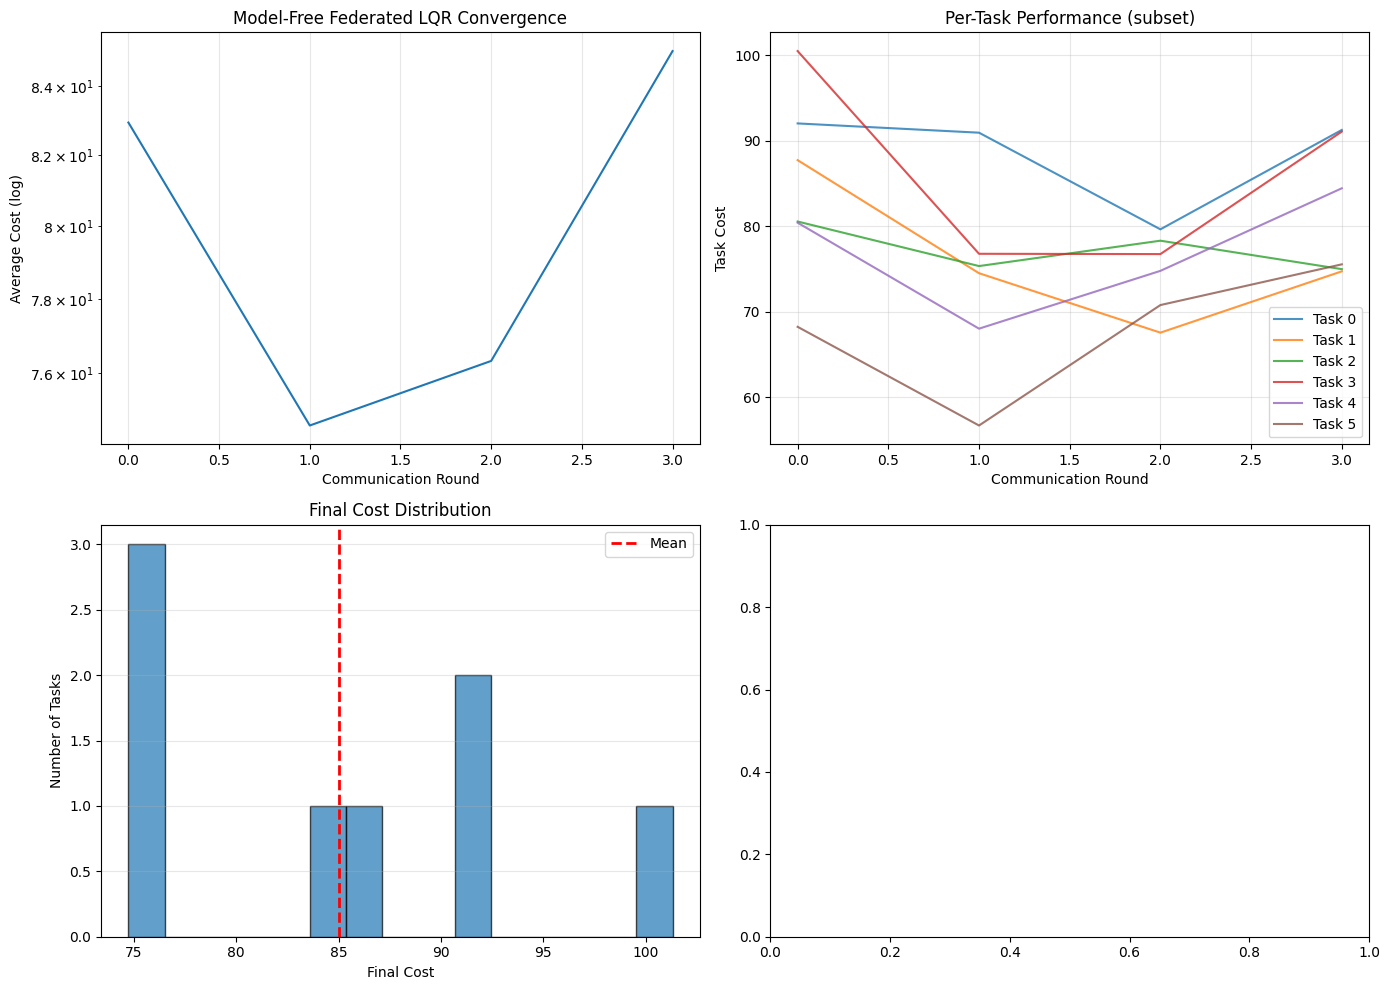

Simulating 'UnifiedK-task-0' for task 'task-0' | 8.0s, 400 steps
  Step 0/399 (t=0.00s)
  Step 50/399 (t=1.00s)
  Step 100/399 (t=2.00s)
  Step 150/399 (t=3.00s)
  Step 200/399 (t=4.00s)
  Step 250/399 (t=5.00s)
  Step 300/399 (t=6.00s)
  Step 350/399 (t=7.00s)
Simulating 'UnifiedK-task-1' for task 'task-1' | 8.0s, 400 steps
  Step 0/399 (t=0.00s)
  Step 50/399 (t=1.00s)
  Step 100/399 (t=2.00s)
  Step 150/399 (t=3.00s)
  Step 200/399 (t=4.00s)
  Step 250/399 (t=5.00s)
  Step 300/399 (t=6.00s)
  Step 350/399 (t=7.00s)
Simulating 'UnifiedK-task-2' for task 'task-2' | 8.0s, 400 steps
  Step 0/399 (t=0.00s)
  Step 50/399 (t=1.00s)
  Step 100/399 (t=2.00s)
  Step 150/399 (t=3.00s)
  Step 200/399 (t=4.00s)
  Step 250/399 (t=5.00s)
  Step 300/399 (t=6.00s)
  Step 350/399 (t=7.00s)
Simulating 'UnifiedK-task-3' for task 'task-3' | 8.0s, 400 steps
  Step 0/399 (t=0.00s)
  Step 50/399 (t=1.00s)
  Step 100/399 (t=2.00s)
  Step 150/399 (t=3.00s)
  Step 200/399 (t=4.00s)
  Step 250/399 (t=5.00s)
  

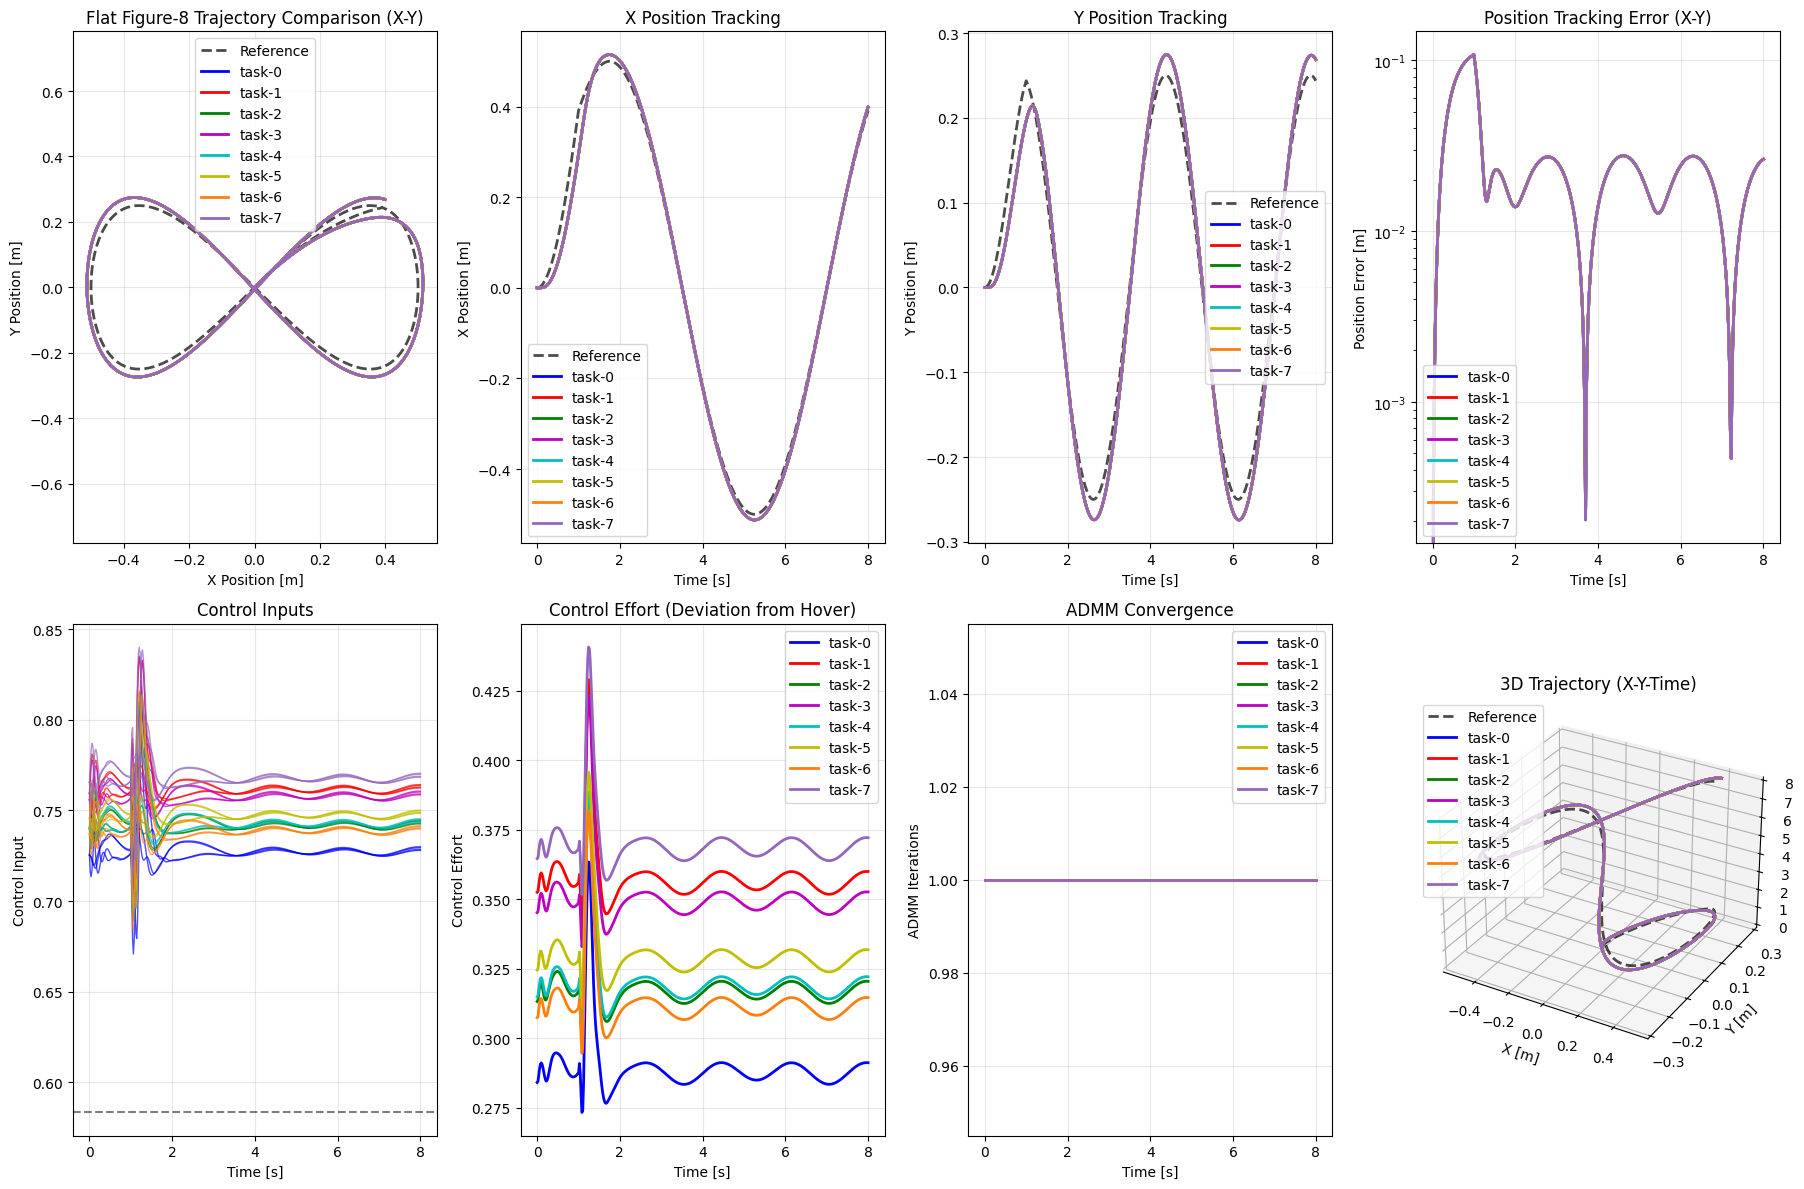


Performance Summary:
--------------------------------------------------------------------------------
Controller           Type       Avg Error    Max Error    Avg Effort   Avg Iters 
--------------------------------------------------------------------------------
task-0               LQR        0.0252       0.1078       0.2893       1.0       
task-1               LQR        0.0252       0.1078       0.3578       1.0       
task-2               LQR        0.0252       0.1078       0.3184       1.0       
task-3               LQR        0.0252       0.1078       0.3505       1.0       
task-4               LQR        0.0253       0.1078       0.3200       1.0       
task-5               LQR        0.0252       0.1078       0.3298       1.0       
task-6               LQR        0.0252       0.1078       0.3126       1.0       
task-7               LQR        0.0252       0.1078       0.3699       1.0       
------------------------------------------------------------------------------

In [56]:


"""
# 3) Train federated model-free LQR
fed = ModelFreeFederatedQuadrotorLQR(
    tasks=tasks,
    K_init=K_init,
    alpha_local=5e-4,
    alpha_global=1e-2,
    local_rounds=8,
    horizon=200,
    r=0.01,
    ns=16,
    batch_size=4
)

K_fed, history = fed.train(num_rounds=40, eval_every=5)
"""

fed = ModelFreeFederatedQuadrotorLQR(
    tasks=tasks,
    K_init=K_init,
    alpha_local=2e-4,     # smaller local step
    alpha_global=5e-3,    # smaller aggregation step
    local_rounds=2,
    horizon=120,          # slightly longer horizon for better signal
    r=0.01,
    ns=6,                 # more samples for smoother gradients
    batch_size=3          # slightly larger batch
)
K_fed, history = fed.train(num_rounds=20, eval_every=5)

# 4) Plot federated training progress
plot_federated_training_progress(history)

# 5) Evaluate unified K across tasks using our plotting framework
_ = plot_unified_K_performance(tasks, K_fed, T_sim=8.0)
